<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Stock-Prediction/Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-12-31")

print(f"Stock: {ticker}")
print(f"Shape: {df.shape}")
print(df.head())


/tmp/ipykernel_584/237674557.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Stock: AAPL
Shape: (1257, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630653  72.389273  71.406681  71.563221  146322800
2020-01-06  72.201424  72.239958  70.503561  70.754028  118387200
2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [3]:
df.dropna(inplace=True)

X = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]

if isinstance(X.columns, pd.MultiIndex):
    X.columns = X.columns.get_level_values(0)
if isinstance(y, pd.DataFrame):
    y = y.squeeze()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


Training samples: 1005
Testing samples : 252


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)


In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


In [7]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)



Linear Regression
  MAE  : 0.8044
  RMSE : 1.0766
  R²   : 0.9982

Random Forest
  MAE  : 17.4438
  RMSE : 24.4079
  R²   : 0.0745


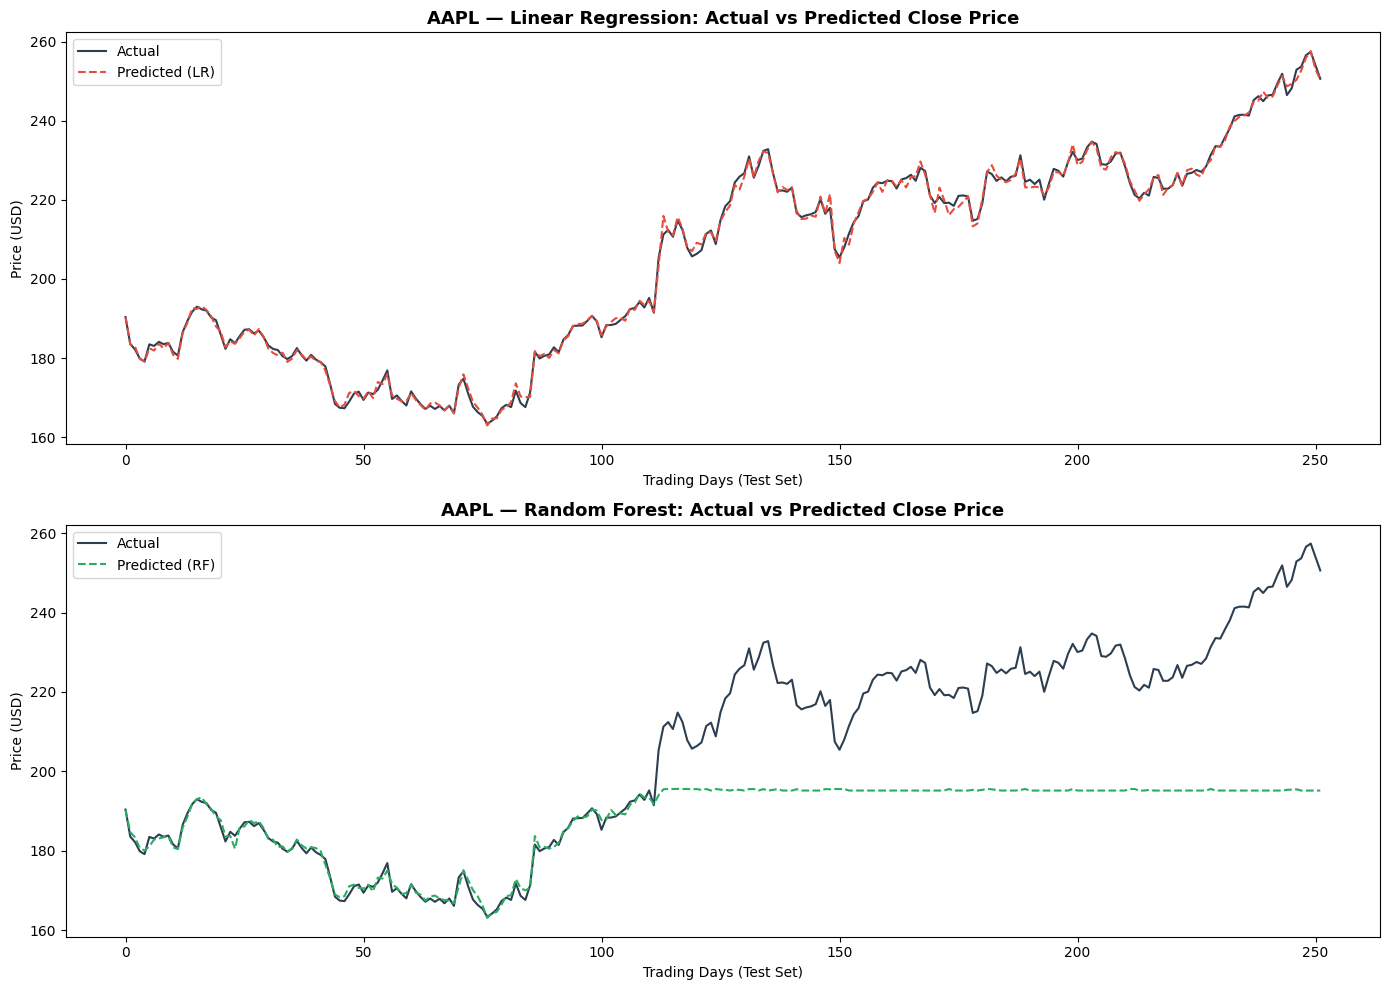

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_test.values, label="Actual", color="#2C3E50", linewidth=1.5)
axes[0].plot(lr_preds, label="Predicted (LR)", color="#E74C3C", linewidth=1.5, linestyle="--")
axes[0].set_title(f"{ticker} — Linear Regression: Actual vs Predicted Close Price", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Trading Days (Test Set)")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

axes[1].plot(y_test.values, label="Actual", color="#2C3E50", linewidth=1.5)
axes[1].plot(rf_preds, label="Predicted (RF)", color="#27AE60", linewidth=1.5, linestyle="--")
axes[1].set_title(f"{ticker} — Random Forest: Actual vs Predicted Close Price", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Trading Days (Test Set)")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()

plt.tight_layout()
plt.savefig("stock_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


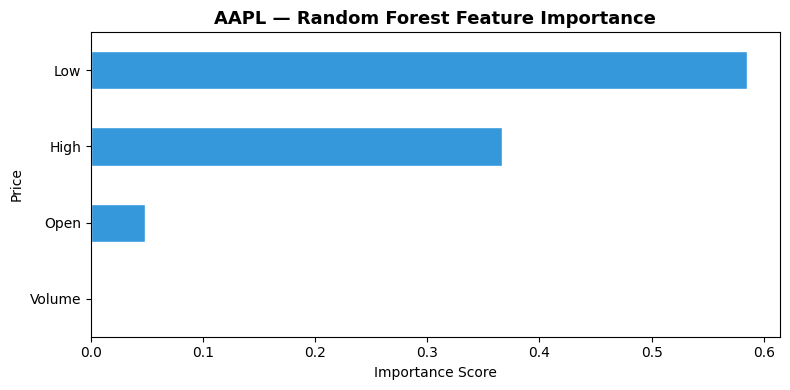

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="#3498DB", edgecolor="white")
plt.title(f"{ticker} — Random Forest Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
